# 04 · Causal inference: average effects, propensity scores, exposure

Estimand: ATE = E[Y(1) − Y(0)] of *assignment* to advertising (intention-to-treat), for visit and conversion.
Full-data results: `uv run causalml causal --mode full` (all 13,979,592 rows; estimation, not prediction).

In [1]:
import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src.utils import REPO_ROOT

FIG, TAB, MET = (REPO_ROOT / "results" / d for d in ("figures", "tables", "metrics"))
pd.set_option("display.float_format", lambda v: f"{v:,.4g}")
pd.set_option("display.max_colwidth", 120)

def fig(name, width=950):
    display(Image(filename=str(FIG / f"{name}.png"), width=width))

def table(name):
    return pd.read_csv(TAB / f"{name}.csv")

def metrics(name):
    return json.loads((MET / f"{name}.json").read_text())

In [2]:
causal = metrics("causal")
for est, info in causal["estimators"].items():
    if isinstance(info, dict):
        print(f"## {est}")
        for k in ("assumptions", "treatment", "outcome_model", "estimand", "limitations"):
            if k in info:
                print(f"  {k}: {info[k]}")

## dim
  assumptions: T randomized independently of (Y(0), Y(1)) and X; SUTVA (no interference, one version of treatment)
  treatment: binary assignment T
  outcome_model: none
  estimand: ATE of assignment (ad eligibility) = ITT, in this benchmark sample
  limitations: ignores covariates (not the most precise unbiased estimator); invalid without randomization
## lin
  assumptions: T randomized independently of (Y(0), Y(1)) and X; SUTVA (no interference, one version of treatment); the linear model need not be correct (Lin 2013)
  treatment: binary assignment T, interacted with centered X
  outcome_model: linear in the linear design matrix, separate slopes per arm (OLS)
  estimand: ATE of assignment (ad eligibility) = ITT, in this benchmark sample
  limitations: only the linear part of E[Y|X] reduces variance; small R^2 for rare binary outcomes
## g_comp_s_lgbm
  assumptions: conditional ignorability T indep. (Y(0), Y(1)) | X (implied by randomization here); positivity 0 < e(x) < 1; SUT

## Every estimator, both outcomes

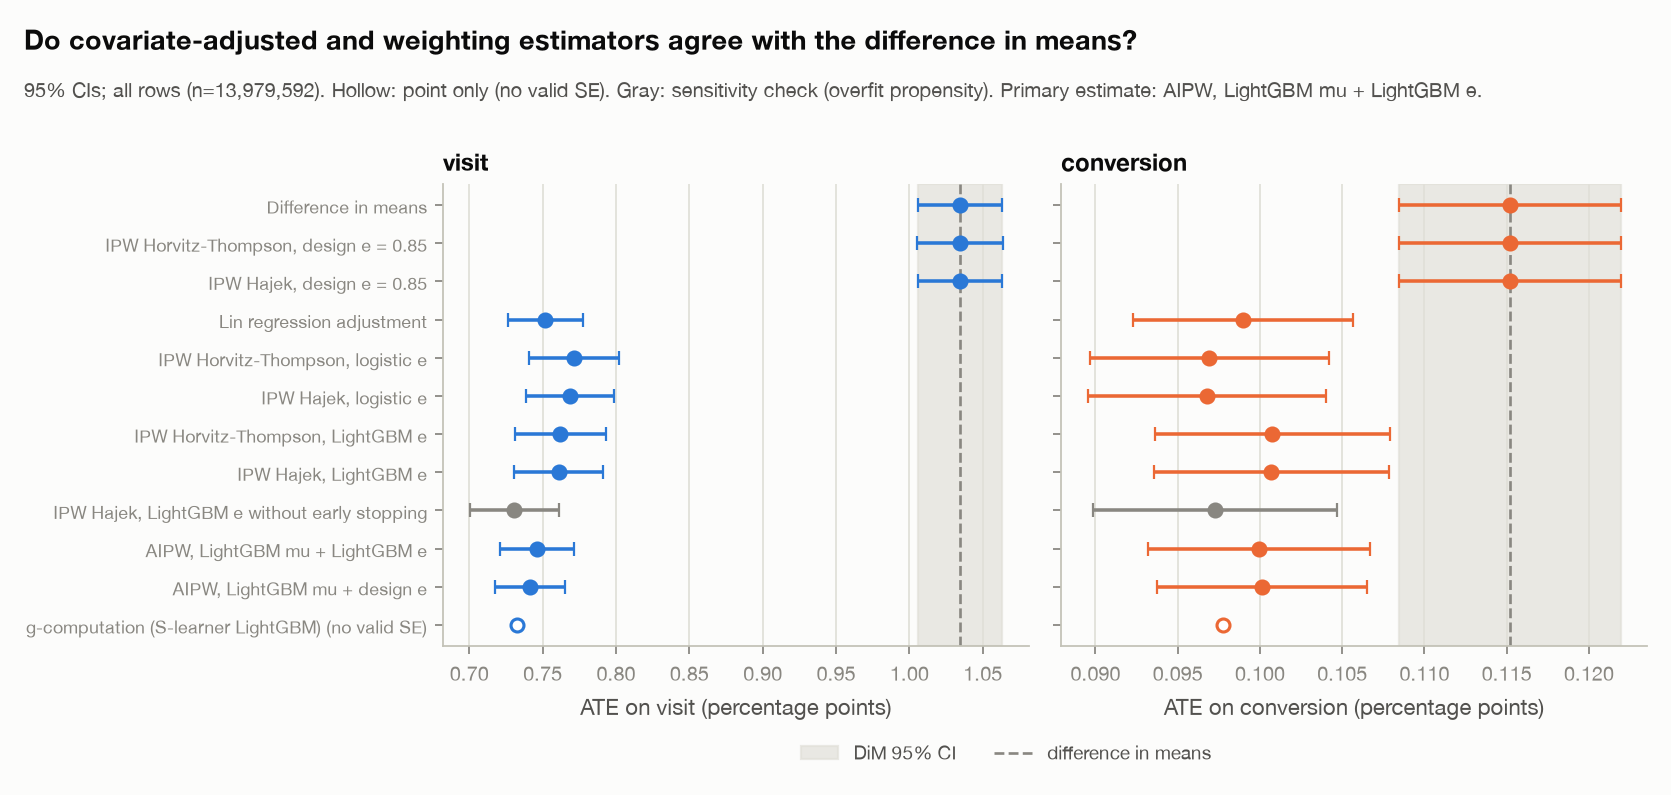

,estimator,label,outcome,estimate,se,ci_low,ci_high,n,sample,se_method
0,dim,Difference in means,visit,0.01034,0.0001463,0.01006,0.01063,13979592,"all rows (n=13,979,592)",Neyman sqrt(s1^2/n1 + s0^2/n0)
1,ipw_ht_design,"IPW Horvitz-Thompson, design e = 0.85",visit,0.01034,0.0001493,0.01005,0.01064,13979592,"all rows (n=13,979,592)","influence function, e fixed"
2,ipw_hajek_design,"IPW Hajek, design e = 0.85",visit,0.01034,0.0001463,0.01006,0.01063,13979592,"all rows (n=13,979,592)","linearized influence function, e fixed"
3,lin,Lin regression adjustment,visit,0.007519,0.0001298,0.007264,0.007773,13979592,"all rows (n=13,979,592)",HC2 sandwich (HC0/HC1 also reported)
4,ipw_ht_logistic,"IPW Horvitz-Thompson, logistic e",visit,0.007716,0.0001566,0.007409,0.008023,13979592,"all rows (n=13,979,592)","influence function, e treated as fixed (conservative)"
5,ipw_hajek_logistic,"IPW Hajek, logistic e",visit,0.007686,0.0001532,0.007386,0.007986,13979592,"all rows (n=13,979,592)","linearized influence function, e treated as fixed (conservative)"
6,ipw_ht_lgbm,"IPW Horvitz-Thompson, LightGBM e",visit,0.007621,0.0001576,0.007313,0.00793,13979592,"all rows (n=13,979,592)","influence function, e treated as fixed (conservative)"
7,ipw_hajek_lgbm,"IPW Hajek, LightGBM e",visit,0.007609,0.0001541,0.007307,0.007911,13979592,"all rows (n=13,979,592)","linearized influence function, e treated as fixed (conservative)"
8,ipw_hajek_lgbm_overfit,"IPW Hajek, LightGBM e without early stopping",visit,0.007308,0.0001561,0.007002,0.007614,13979592,"all rows (n=13,979,592)","linearized influence function, e treated as fixed"
9,aipw_lgbm,"AIPW, LightGBM mu + LightGBM e",visit,0.007461,0.0001276,0.007211,0.007711,13979592,"all rows (n=13,979,592)",efficient influence function


In [3]:
fig("causal_forest"); table("causal_ate_estimates")

The difference in means and every IPW variant that uses the *design* propensity (0.85 for everyone) agree with each
other; every estimator that conditions on the features — Lin regression adjustment, IPW with an estimated
propensity, AIPW, g-computation — lands 13-28% lower. Because the estimated propensity is correlated with the
outcomes, the raw treated-vs-control comparison over-states the effect. The doubly robust AIPW estimate is primary.

In [4]:
print(json.dumps(causal["implication"], indent=1, default=str)[:2500])

{
 "text": "Treatment was randomized within each advertiser test, but in the pooled benchmark T is weakly predictable from X and the imbalance is prognostic (treated users have higher predicted baseline outcomes, so the difference in means overstates the effect of assignment). The data behave like a conditionally randomized (stratified) experiment: identification needs T indep. (Y(0), Y(1)) | X. visit: AIPW 0.7461 pp (95% CI 0.7211-0.7711) vs difference in means 1.0342 pp; DiM - AIPW = 0.2881 pp (paired SE 0.0084, z = 34.4), i.e. the adjusted effect is 28% smaller than DiM; the mean predicted untreated outcome mu0(X) differs by +0.2710 pp (SE 0.0080) between the treated and control arms; conversion: AIPW 0.1000 pp (95% CI 0.0932-0.1067) vs difference in means 0.1152 pp; DiM - AIPW = 0.0152 pp (paired SE 0.0016, z = 9.8), i.e. the adjusted effect is 13% smaller than DiM; the mean predicted untreated outcome mu0(X) differs by +0.0128 pp (SE 0.0014) between the treated and control arms. C

## Propensity scores

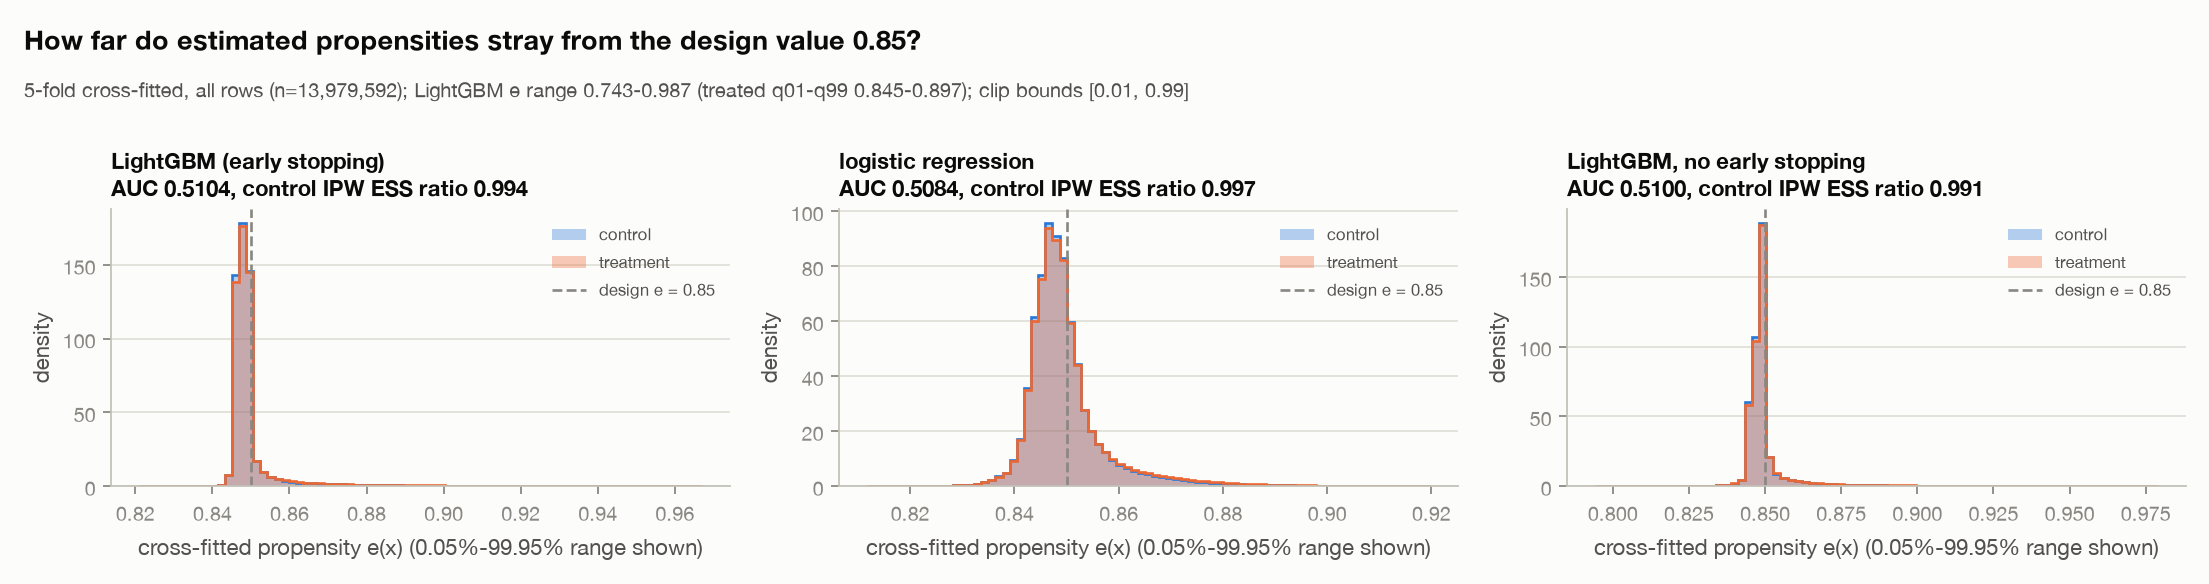

{
 "design_propensity": 0.85,
 "clip_bounds": [
  0.01,
  0.99
 ],
 "sample": "all rows (n=13,979,592)",
 "folds": 5,
 "lightgbm": {
  "by_arm": {
   "treatment": {
    "n": 11882655,
    "mean": 0.8501080120655029,
    "sd": 0.00923830418585057,
    "quantiles": {
     "q00": 0.7430664574546901,
     "q01": 0.8447830420160688,
     "q05": 0.8455472924268933,
     "q25": 0.8464587685078386,
     "q50": 0.8485868154382433,
     "q75": 0.8491894171781786,
     "q95": 0.8622403961086867,
     "q99": 0.8973210322151819,
     "q100": 0.9871280533735652
    },
    "ipw_ess": 11881410.02684708,
    "ipw_ess_ratio": 0.9998952276950799,
    "max_weight_share": 9.626860553460951e-08
   },
   "control": {
    "n": 2096937,
    "mean": 0.8494593050656731,
    "sd": 0.0070210517287733545,
    "quantiles": {
     "q00": 0.7543600006722951,
     "q01": 0.8447830420160688,
     "q05": 0.8455472924268933,
     "q25": 0.8463747269580152,
     "q50": 0.8485518941483391,
     "q75": 0.8491300453474293,
  

In [5]:
fig("causal_propensity"); print(json.dumps(causal["propensity"], indent=1, default=str)[:1500])

In a clean randomized experiment the propensity is a known constant and modelling it only reduces variance. In
observational data it is the whole identification strategy: you must model who got treated, and you can only adjust
for what you measured. The demo below makes an observational dataset out of the experiment by dropping users with a
probability that depends on a strong predictor and on treatment, then checks which estimators recover the full-data
answer.

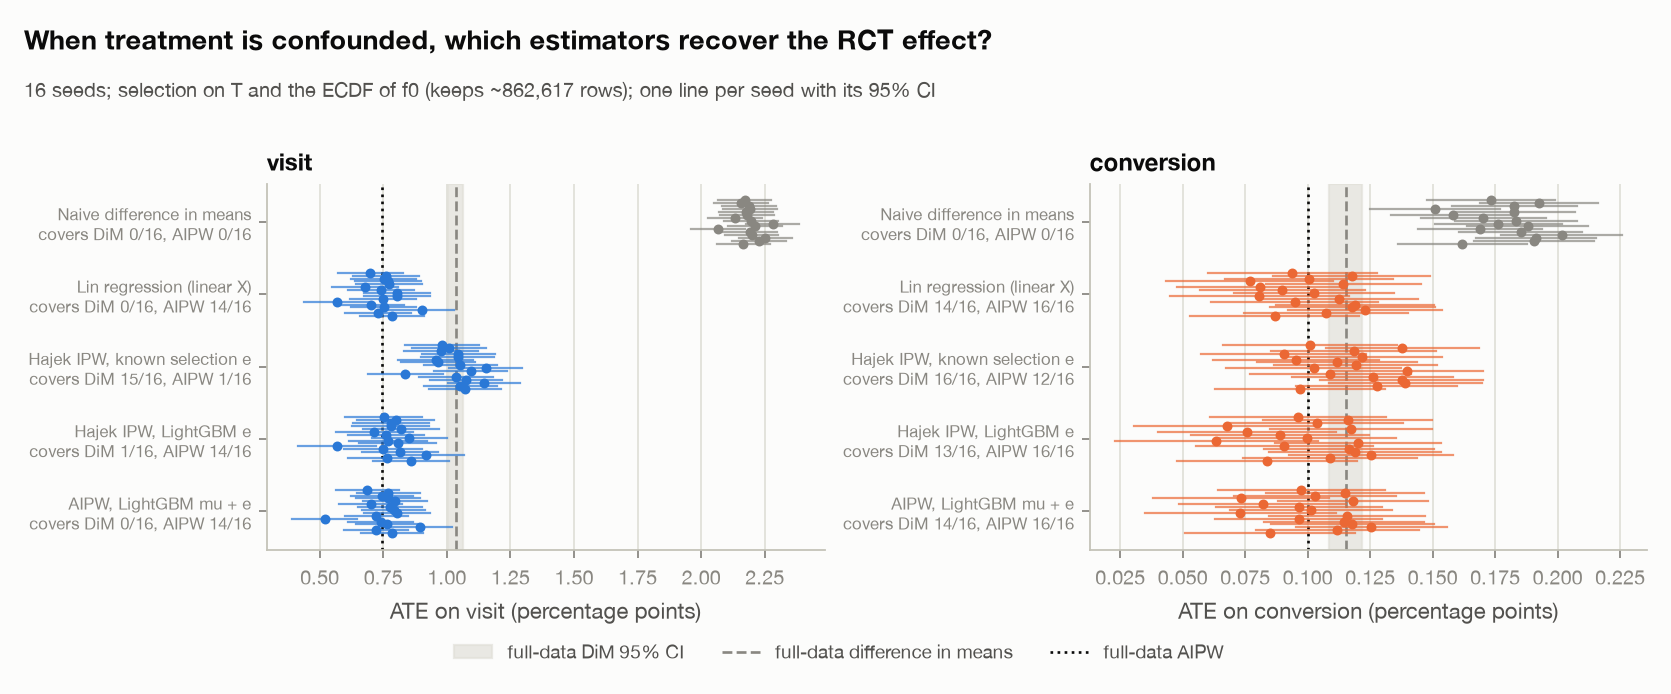

seed  estimate        se    ci_low  \
outcome    estimator                                                       
conversion aipw_lgbm                   7.5  0.001016 0.0001678 0.0006874   
           ipw_hajek_known_selection   7.5  0.001172  0.000166 0.0008461   
           ipw_hajek_lgbm              7.5 0.0009959 0.0001789 0.0006452   
           lin                         7.5  0.001011 0.0001674 0.0006834   
           naive_dim                   7.5  0.001786  0.000126  0.001539   
visit      aipw_lgbm                   7.5  0.007493 0.0006387  0.006242   
           ipw_hajek_known_selection   7.5   0.01031 0.0007366  0.008866   
           ipw_hajek_lgbm              7.5  0.007819 0.0007686  0.006312   
           lin                         7.5   0.00748 0.0006568  0.006192   
           naive_dim                   7.5   0.02187 0.0005381   0.02081   

                                      ci_high         n  benchmark_dim  \
outcome    estimator                                                     
conversion aipw_lgbm                 0.001345 8.627e+05       0.001152   
           ipw_hajek_known_selection 0.001497 8.627e+05       0.001152   
           ipw_hajek_lgbm            0.001347 8.627e+05       0.001152   
           lin                        0.00134 8.627e+05       0.001152   
           naive_dim                 0.002033 8.627e+05       0.001152   
visit      aipw_lgbm                 0.008745 8.627e+05        0.01034   
           ipw_hajek_known_selection  0.01175 8.627e+05        0.01034   
           ipw_hajek_lgbm            0.009325 8.627e+05        0.01034   
           lin                       0.008767 8.627e+05        0.01034   
           naive_dim                  0.02292 8.627e+05        0.01034   

                                      covers_dim  benchmark_aipw  covers_aipw  
outcome    estimator                                                           
conversion aipw_lgbm                       0.875       0.0009996            1  
           ipw_hajek_known_selection           1       0.0009996         0.75  
           ipw_hajek_lgbm                 0.8125       0.0009996            1  
           lin                             0.875       0.0009996            1  
           naive_dim                           0       0.0009996            0  
visit      aipw_lgbm                           0        0.007461        0.875  
           ipw_hajek_known_selection      0.9375        0.007461       0.0625  
           ipw_hajek_lgbm                 0.0625        0.007461        0.875  
           lin                                 0        0.007461        0.875  
           naive_dim                           0        0.007461            0

In [6]:
fig("causal_obs_demo"); table("causal_obs_demo_replicates").groupby(["outcome", "estimator"]).mean(numeric_only=True)

## The effect of actually seeing an ad

Randomized assignment is an instrument for exposure: it moves exposure (control users are never exposed) and plausibly
affects outcomes only through ads shown. With one-sided non-compliance, the Wald ratio ITT_Y / ITT_E is the average
effect of exposure on the users who were exposed.

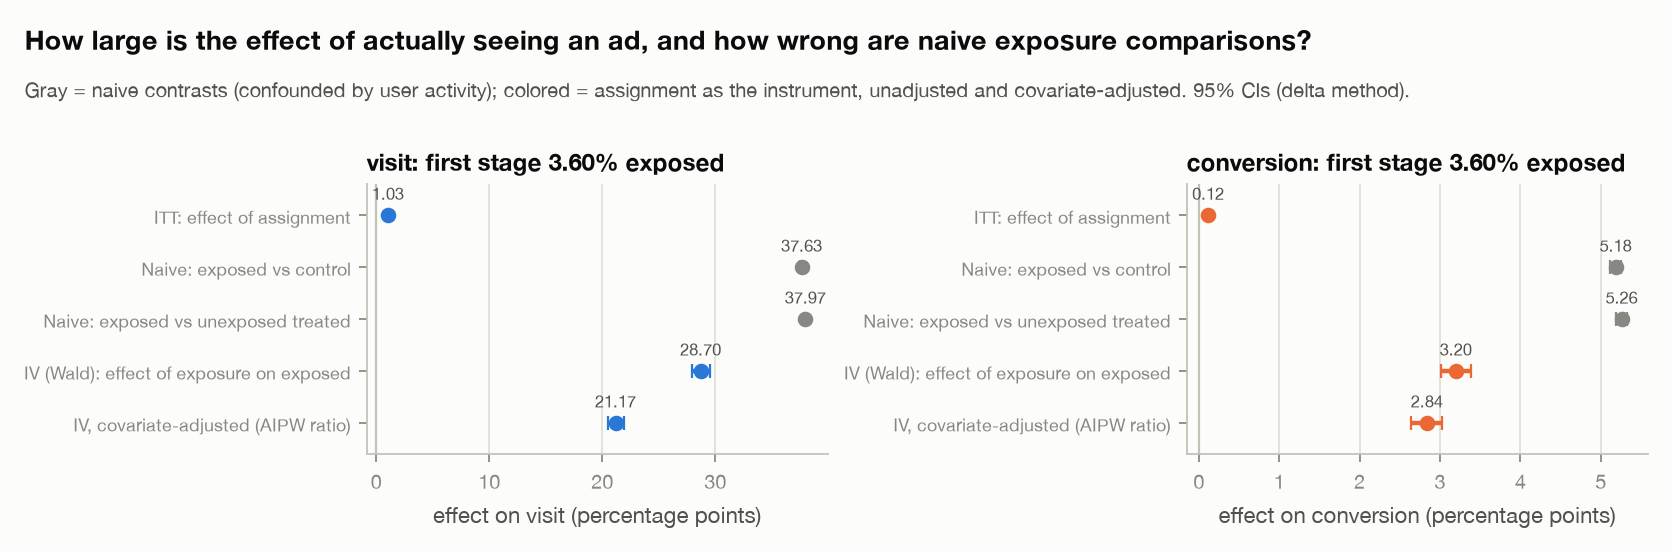

{
 "assumptions": {
  "random_assignment": "T randomized (instrument independent of potential outcomes and exposures)",
  "exclusion_restriction": "assignment affects visit/conversion only through ad exposure",
  "monotonicity": "no defiers; trivially true because control users cannot be exposed",
  "relevance": "first stage P(E=1|T=1) - P(E=1|T=0) != 0",
  "sutva": "no interference between users"
 },
 "why_naive_is_biased": "Exposure is not randomized: among eligible users, those who are online more (and so more likely to visit or buy anyway) are more likely to be shown an ad. Exposed-vs-control compares these high-baseline users with an average user; exposed-vs-unexposed-treated compares them with the low-activity users who were never reached. Both mix the ad effect with baseline differences (E[Y(0)|exposed] > E[Y(0)]); the IV uses only the randomized contrast and rescales it by the first stage.",
 "visit": {
  "itt": {
   "estimate": 0.010342403129198284,
   "se": 0.0001463164506603

In [7]:
fig("causal_exposure_iv"); print(json.dumps(causal["exposure"], indent=1, default=str)[:2500])

## The same estimators on the development sample, using the propensity from the CATE stage

In [8]:
from src.causal.ate import difference_in_means, ipw_hajek

s = pd.read_parquet(REPO_ROOT / "data/processed/scores_dev.parquet")
s = s[s.split == 2]
for y in ["visit", "conversion"]:
    dim = difference_in_means(s[y].to_numpy(), s.treatment.to_numpy())
    haj = ipw_hajek(s[y].to_numpy(), s.treatment.to_numpy(), s.propensity.to_numpy())
    print(f"{y:10s} DiM {dim['estimate']:.5f}  Hajek-IPW {haj['estimate']:.5f}  (dev test rows: {len(s):,})")

visit      DiM 0.01034  Hajek-IPW 0.00945  (dev test rows: 139,795)
conversion DiM 0.00113  Hajek-IPW 0.00101  (dev test rows: 139,795)
